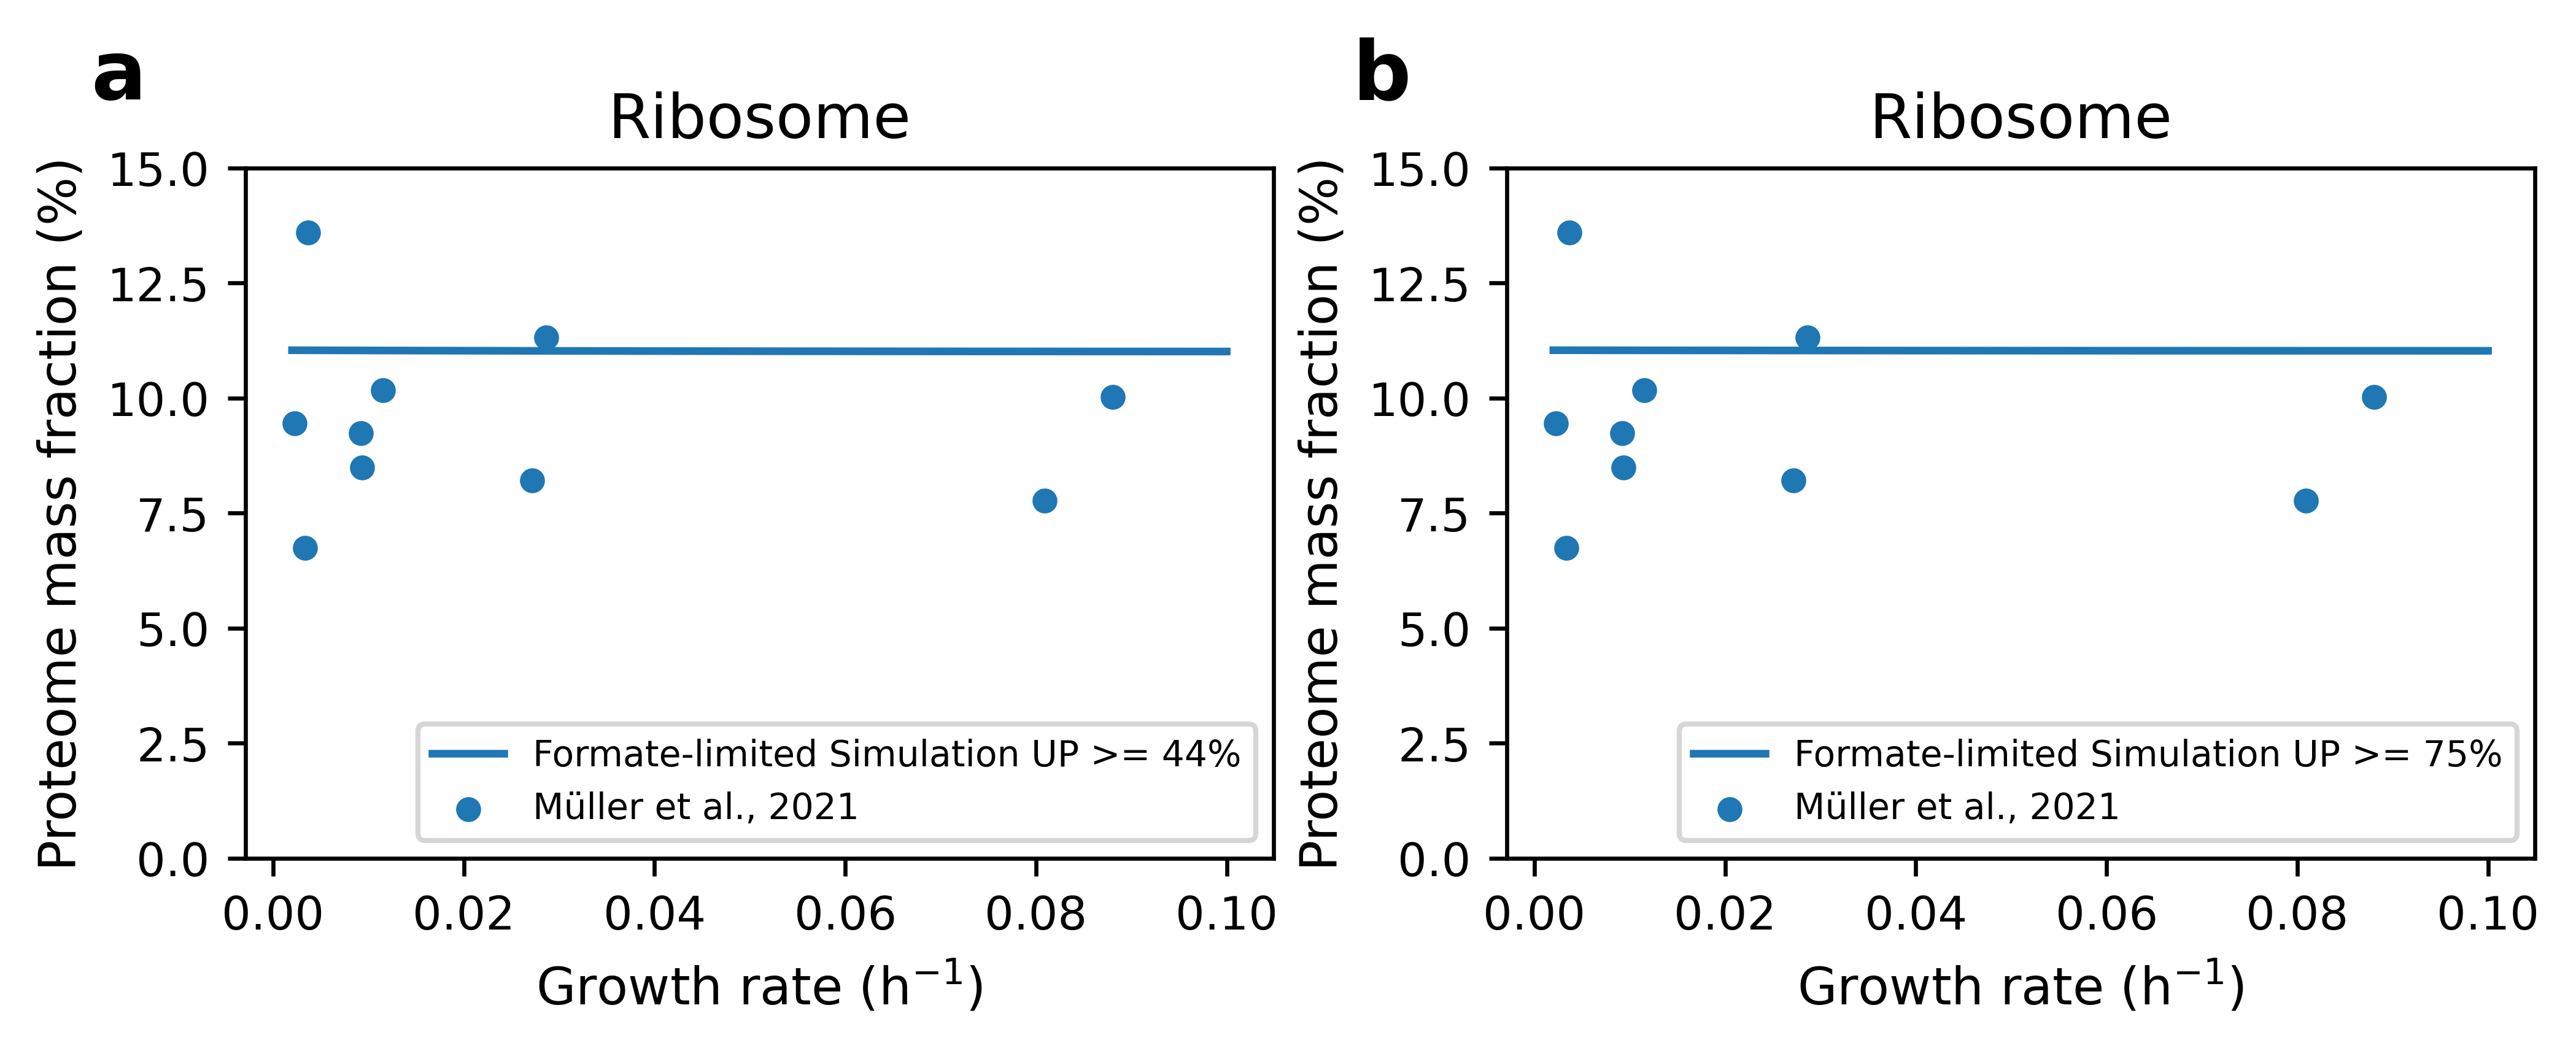

In [1]:
from simulation import Simulation
from extract_fluxes import Fluxes
import cobra
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def limitation_simulation(up_ratio):
    total_protein_mass=0.6
    up_formate_ratio=up_ratio*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    sim.set_parameter(model_file='pcMMP.xml', objective="R895", GAM=25, NGAM=1, excel_file='pcMMP.xlsx')
    sim.set_constraint = [f"UP >= {up_formate_ratio}"]
    sim.close_reactions(closed_reactions)
    results = {"mu_list": [],"ribosome_list": [], "total_proteins": []}
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):

        sim.file_path = f"output/lp_file_formate_UP{i}.lp"
        sim.output_file = f"output/output_formate_UP{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_formate_UP{i}.lp')
            results["mu_list"].append(mu)
            
            total_protein = fluxes.extract_reaction_flux("total_protein")
            results["ribosome_list"].append((fluxes.extract_reaction_flux("ribosome_mass") / total_protein)*100)
            results["total_proteins"].append(total_protein)
          
        else:
            print(f"mu={mu} is not optimal")

    return results

def plot(results_formate_up_44,results_formate_up_75):
    
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })


    exp_Formate_ribsome_x=[0.003378591, 0.002283602, 0.003677198, 0.009335012, 0.009236709, 0.011536363, 0.080918156, 0.088069874, 0.027194596, 0.028672867]
    exp_Formate_ribsome_y=[6.737044289, 9.443378583, 13.58925051, 8.493282875, 9.241842863, 10.16314822, 7.773513233, 10.0191943, 8.205375018, 11.31477965]
    fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=600)
    subplot_labels = ["a", "b"]
    axes[0].plot(results_formate_up_44["mu_list"], results_formate_up_44['ribosome_list'], label="Formate-limited Simulation UP >= 44%", color='#1f77b4')
    axes[0].scatter(exp_Formate_ribsome_x, exp_Formate_ribsome_y, color='#1f77b4', s=15, label="Müller et al., 2021")
    axes[0].set_title("Ribosome")
    axes[0].set_ylabel("Proteome mass fraction (%)")
    axes[0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0].set_ylim(0, 15)
    axes[0].legend(loc="lower right")
    axes[0].text(-0.15, 1.1, subplot_labels[0], transform=axes[0].transAxes,fontsize=16, fontweight='bold')

    axes[1].plot(results_formate_up_75["mu_list"], results_formate_up_75['ribosome_list'], label="Formate-limited Simulation UP >= 75%", color='#1f77b4')
    axes[1].scatter(exp_Formate_ribsome_x, exp_Formate_ribsome_y, color='#1f77b4', s=15, label="Müller et al., 2021")
    axes[1].set_title("Ribosome")
    axes[1].set_ylabel("Proteome mass fraction (%)")
    axes[1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1].set_ylim(0, 15)
    axes[1].legend(loc="lower right")
    axes[1].text(-0.15, 1.1, subplot_labels[1], transform=axes[1].transAxes,fontsize=16, fontweight='bold')
    plt.subplots_adjust(wspace=0.4)

    plt.tight_layout()
    plt.savefig("Figures/ribosome_proteome_formate_limited_with_different_UP.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    results_formate_up_44 = limitation_simulation(up_ratio=0.44)
    results_formate_up_75 = limitation_simulation(up_ratio=0.75)
    plot(results_formate_up_44,results_formate_up_75)